In [234]:
import pandas as pd
import numpy as np
import os

pd.set_option("display.max_columns", None)  # no column truncation
pd.set_option("display.width", 0)  # prevents line wrapping

In [235]:
df = pd.read_csv("../data/proc/data_prep_kz.csv")
df.head()

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_69610/3042881208.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/proc/data_prep_kz.csv")


,NUMERO DE ACEPTACION,RUT PROBABLE IMPORTADOR,PAIS DE ORIGEN,PUERTO DE EMBARQUE,PUERTO DE DESEMBARQUE,COMPANIA DE TRANSPORTE,TIPO DE BULTO,CLAUSULA,CANTIDAD DE BULTO,CANTIDAD UNIDADES FISICAS,UNIDAD DE MEDIDA FISICA,FECHA_TRANS,DIFF_DAYS,FOB_POR_BULTO,FLETE_POR_BULTO,SEGURO_POR_BULTO,PESO BRUTO POR CONTENEDOR,ITEMS POR CONTENEDOR
0,20966331,76056375,ECUADOR,OTROS PUERTOS MEXICO,SAN ANTONIO,HAPAG-LLOYD,CONTENEDOR REFRIGERADO 40,FOB,2,1080.0,CAJAS,2024-01-30,-19.0,3240.00,654.0,64.80,10902.6,0.5
1,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,300.0,CAJA,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
2,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,1400.0,CAJA,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
3,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,50.0,CAJA,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0
4,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,6000.0,KN,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0


In [236]:
df["FECHA"] = pd.to_datetime(df["FECHA_TRANS"], format="%Y-%m-%d")
daily_df = df.copy()
df["FECHA"] = df["FECHA"].dt.strftime("%Y-%U")
weekly_df = pd.DataFrame({"FECHA": df["FECHA"].dropna().sort_values().unique()})
df.head()

,NUMERO DE ACEPTACION,RUT PROBABLE IMPORTADOR,PAIS DE ORIGEN,PUERTO DE EMBARQUE,PUERTO DE DESEMBARQUE,COMPANIA DE TRANSPORTE,TIPO DE BULTO,CLAUSULA,CANTIDAD DE BULTO,CANTIDAD UNIDADES FISICAS,UNIDAD DE MEDIDA FISICA,FECHA_TRANS,DIFF_DAYS,FOB_POR_BULTO,FLETE_POR_BULTO,SEGURO_POR_BULTO,PESO BRUTO POR CONTENEDOR,ITEMS POR CONTENEDOR,FECHA
0,20966331,76056375,ECUADOR,OTROS PUERTOS MEXICO,SAN ANTONIO,HAPAG-LLOYD,CONTENEDOR REFRIGERADO 40,FOB,2,1080.0,CAJAS,2024-01-30,-19.0,3240.00,654.0,64.80,10902.6,0.5,2024-04
1,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,300.0,CAJA,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0,2023-02
2,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,1400.0,CAJA,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0,2023-02
3,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,50.0,CAJA,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0,2023-02
4,20999790,76197286,VIETNAM,HONG KONG,VALPARAISO,ONE,CONTENEDOR REFRIGERADO 40,CIF,2,6000.0,KN,2023-01-11,357.0,23788.16,857.5,54.34,12690.0,2.0,2023-02


In [237]:
df.shape

(7488896, 19)

In [238]:
df['PUERTO DE EMBARQUE'].unique()

array(['OTROS PUERTOS MEXICO', 'HONG KONG', 'SHANGAI',
       'OTROS PTOS.DE CHINA', 'CALLAO', 'BUENAVENTURA',
       'OTROS PTOS. COLOMBIA', 'HAMBURGO', 'GUAYAQUIL', 'AMBERES',
       'OTROS PTOS. PANAMA', 'CRISTOBAL', 'BALBOA', 'OTROS PTOS.BRASIL',
       'NEW YORK', 'ROTTERDAM', 'MIAMI', 'KAOHSIUNG', 'BUSAN CY (PUSAN)',
       'OTROS PTOS.AMERICA', 'MANZANILLO', 'OTROS PTOS.PORTUGAL',
       'OTROS PTOS.EUROPA', 'SAVANAH', 'OTROS PTOS. ECUADOR', 'GENOVA',
       'DAIREN', 'VALENCIA', 'BARCELONA', 'COSTA DEL PACIFICO',
       'OTROS PTO.ASIATICOS', 'OTROS PTOS.ESPANA', 'LONDRES',
       'OTROS PTO.BELGICA', 'OTROS PTOS. DE PERU', 'ALGECIRAS',
       'SALVADOR', 'OAKLAND', 'OTROS PTOS.DE ITALIA', 'SANTOS',
       'OTROS PTOS.ALEMANIA', 'PHILADELPHIA', 'RIO DE JANEIRO',
       'OTROS PTOS.DE COREA', 'LOS ANGELES', 'SEATTLE', 'EVERGLADES',
       'CHARLESTON', 'SAO PAULO', 'OTROS ANT.HOLANDESA', 'LE HAVRE',
       'OTROS PTOS.INGLATERR', 'OTROS PTOS. CHILENOS', 'COPENHAGEN',
       'VAL

In [239]:
grouped_coasts = {
    'GALVESTON': 'NAE',
    'OTROS PTOS VENEZUELA': 'SAE',
    'PUERTO ANGAMOS': 'SAW',
    'SAN  ANTONIO': 'SAW',
    'OTROS PTOS.INGLATERR': 'NE',
    'OTROS PTOS.AMERICA': 'NAE',
    'LISBOA': 'SE',
    'ZEEBRUGGE': 'NE',
    'NAPOLES': 'SE',
    'DAIREN': 'FE',
    'SALVADOR': 'SAE',
    'CHARLESTON': 'NAE',
    'KEELUNG': 'FE',
    'OTROS PTOS. CHILENOS': 'SAW',
    'OTROS PTOS.DE ITALIA': 'SE',
    'NEW HAVEN': 'NAE',
    'OTROS PTOS. COLOMBIA': 'SAW',
    'HOUSTON': 'NAE',
    'OTROS PTOS. DE PERU': 'SAW',
    'SALERNO': 'SE',
    'OTROS PTOS.EUROPA': 'NE',
    'CUTTER COVE': 'NAW',
    'PALENA CARRENLEUFU': 'SAW',
    'SEATTLE': 'NAW',
    'LOS ANGELES': 'NAW',
    'RIJEKA': 'SE',
    'CUXHAVEN': 'NE',
    'OTROS PTOS.HOLANDA': 'NE',
    'AMSTERDAM': 'NE',
    'TORONTO': 'NAE',
    'PORT ARTHUR': 'NAE',
    'OTROS PTOS.TAIWAN': 'FE',
    'LIECHTENSTEIN': 'NE',
    'OTROS PTOS.BRASIL': 'SAE',
    'MENDOZA': 'SAE',
    'OTROS PTOS. ECUADOR': 'SAW',
    'BALTIMORE': 'NAE',
    'CORONEL': 'SAW',
    'AEROPUERTO COM. A. MERINO B.': 'SAW',
    'OTROS PTOS PORTUGAL': 'SE',
    'OTROS PTOS.PORTUGAL': 'SE',
    'PORTLAND': 'NAW',
    'KOTKA': 'NE',
    'OULO': 'NE',
    'OSLO': 'NE',
    'OTROS PTO.NORUEGA': 'NE',
    'HELSINKI': 'NE',
    'SANTOS': 'SAE',
    'BILBAO': 'SE',
    'GOTEMBURGO': 'NE',
    'FRANKFURT': 'NE',
    'OLDENBURG': 'NE',
    'LE HAVRE': 'NE',
    'YOKOHAMA': 'FE',
    'CRISTOBAL': 'NAE',
    'COSTA DEL PACIFICO': 'NAW',
    'GNL MEJILLONES': 'SAW',
    'CURACAO': 'NAE',
    'OTROS PTOS. CHILENOS': 'SAW',
    'SAN FRANCISCO': 'NAW',
    'ROSTOCK': 'NE',
    'BARRANQUILLA': 'NAE',
    'CIUDAD DEL CABO': 'AF',
    'HELSIMBORG': 'NE',
    'AUGUSTA': 'SE',
    'OTROS PTOS. PANAMA': 'NAE',
    'OTROS PTOS.ALEMANIA': 'NE',
    'OTROS PTOS BULGARIA': 'SE',
    'OTROS PTOS.SUECIA': 'NE',
    'PARANAGUA': 'SAE',
    'OSAKA': 'FE',
    'OTROS PTO.SUD AFRIC': 'AF',
    'VANCOUVER': 'NAW',
    'SALINAS': 'SAW',
    'COLUMBRES': 'SE',
    'NEW YORK': 'NAE',
    'PUERTOS DEL GOLFO': 'NAE',
    'COSTA DE ATLANTICO': 'NAE',
    'TAMPA': 'NAE',
    'QUEBEC': 'NAE',
    'OTROS PUERTOS CANADA': 'NAE',
    'AMBERES': 'NE',
    'LIVERPOOL': 'NE',
    'SAVONA': 'SE',
    'OTROS PTOS.ESPANA': 'SE',
    'LIORNA,LIVORNO': 'SE',
    'OTROS PTO.OCEANIA': 'OC',
    'NORFOLK': 'NAE',
    'VALENCIA': 'SE',
    'COLON': 'NAE',
    'OTROS PTOS.FRANCIA': 'SE',
    'OTROS PTOS.ARGENTINA': 'SAE',
    'VERACRUZ': 'NAE',
    'BREMEN': 'NE',
    'OTROS PTOS PORTUGAL': 'SE',
    'OTROS PTOS.ESPANA': 'SE',
    'AALBORG': 'NE',
    'OTROS PTOS.JAPONESES': 'FE',
    'BUENAVENTURA': 'SAW',
    'OTROS PTO.BANGLADESH': 'ME',
    'OTROS PTOS. ECUADOR ': 'SAW',
    'OTROS PTOS.TAIWAN ': 'FE',
    'COATZACOALES': 'NAE',
    'PANAMA': 'NAW',
    'OTROS PTOS.DE COREA': 'FE',
    'OTROS PTOS.ARGENTINA ': 'SAE',
    'IQUIQUE': 'SAW',
    'RIO DE JANEIRO': 'SAE',
    'RIO GRANDE DEL SUR': 'SAE',
    'BUENOS AIRES': 'SAE',
    'OTROS PTOS.URUGUAY': 'SAE',
    'MONTEVIDEO': 'SAE',
    'BAHIA BLANCA': 'SAE',
    'SAO PAULO': 'SAE',
    'ARICA': 'SAW',
    'MEJILLONES': 'SAW',
    'PATILLOS': 'SAW',
    'CALDERA': 'SAW',
    'SAN VICENTE': 'SAW',
    'LIRQUEN': 'SAW',
    'TALCAHUANO': 'SAW',
    'VALPARAISO': 'SAW',
    'SAN  ANTONIO': 'SAW',
    'GUAYACAN': 'SAW',
    'OTROS PTOS. DE PERU': 'SAW',
    'CALLAO': 'SAW',
    'ILO': 'SAW',
    'GUAYAQUIL': 'SAW',
    'OTROS PTOS. ECUADOR': 'SAW',
    'OTROS PTOS.BRASIL': 'SAE',
    'SALVADOR': 'SAE',
    'SANTOS': 'SAE',
    'PARANAGUA': 'SAE',
    'RIO GRANDE DEL SUR': 'SAE',
    'AMSTERDAM': 'NE',
    'ROTTERDAM': 'NE',
    'HAMBURGO': 'NE',
    'LONDRES': 'NE',
    'LE HAVRE ': 'NE',
    'LA PALLICE': 'NE',
    'ZEEBRUGGE ': 'NE',
    'BREMEN ': 'NE',
    'CUXHAVEN ': 'NE',
    'ROSTOCK ': 'NE',
    'FRANKFURT ': 'NE',
    'NUREMBERG': 'NE',
    'OLDENBURG ': 'NE',
    'OTROS PTOS.ALEMANIA ': 'NE',
    'OTROS PTOS.HOLANDA ': 'NE',
    'OTROS PTO.BELGICA': 'NE',
    'OTROS PTOS.INGLATERR ': 'NE',
    'COPENHAGEN': 'NE',
    'AARHUS': 'NE',
    'AALBORG ': 'NE',
    'GOTEMBURGO ': 'NE',
    'HELSIMBORG ': 'NE',
    'OSLO ': 'NE',
    'STAVANGER': 'NE',
    'HELSINKI ': 'NE',
    'KOTKA ': 'NE',
    'OULO ': 'NE',
    'OTROS PTO.NORUEGA ': 'NE',
    'OTROS  PTO.DINAMARCA': 'NE',
    'OTROS PTOS.SUECIA ': 'NE',
    'OTROS PTO.FINLANDIA': 'NE',
    'GENOVA': 'SE',
    'VALENCIA ': 'SE',
    'BARCELONA': 'SE',
    'BILBAO ': 'SE',
    'ALGECIRAS': 'SE',
    'CADIZ': 'SE',
    'SEVILLA': 'SE',
    'LISBOA ': 'SE',
    'SETUBAL': 'SE',
    'MARSELLA': 'SE',
    'LIORNA,LIVORNO ': 'SE',
    'SAVONA ': 'SE',
    'AUGUSTA ': 'SE',
    'NAPOLES ': 'SE',
    'SALERNO ': 'SE',
    'CONSTANZA': 'SE',
    'VARNA': 'SE',
    'RIJEKA ': 'SE',
    'OTROS PTOS.PORTUGAL ': 'SE',
    'OTROS PTOS.ESPANA ': 'SE',
    'OTROS PTOS.DE ITALIA ': 'SE',
    'OTROS PTOS.FRANCIA ': 'SE',
    'OTROS PTOS BULGARIA ': 'SE',
    'OTROS PTO.DE RUMANIA': 'SE',
    'HONG KONG': 'FE',
    'SHANGAI': 'FE',
    'OTROS PTOS.DE CHINA': 'FE',
    'DAIREN ': 'FE',
    'KAOHSIUNG': 'FE',
    'KEELUNG ': 'FE',
    'OTROS PTOS.TAIWAN  ': 'FE',
    'BUSAN CY (PUSAN)': 'FE',
    'OTROS PTOS.DE COREA ': 'FE',
    'YOKOHAMA ': 'FE',
    'KOBE': 'FE',
    'OSAKA ': 'FE',
    'NAGOYA': 'FE',
    'SHIMIZUI': 'FE',
    'FUKUYAMA': 'FE',
    'MOJI': 'FE',
    'OTROS PTOS.JAPONESES ': 'FE',
    'MANILA': 'FE',
    'OTROS PTOS.FILIPINAS': 'FE',
    'OTROS PTO.SINGAPURE': 'FE',
    'OTROS PTO.ASIATICOS': 'FE',
    'OTROS PTO.IRAN NO ES': 'ME',
    'OTROS PTO.INDIA NO E': 'IND',
    'CALCUTA': 'IND',
    'OTROS PTO.BANGLADESH ': 'IND',
    'DURBAM': 'AF',
    'CIUDAD DEL CABO ': 'AF',
    'OTROS PTO.DE AFRICA': 'AF',
    'OTROS PTO.SUD AFRIC ': 'AF',
    'SIDNEY': 'OC',
    'ADELAIDA': 'OC',
    'PREMANTLE': 'OC',
    'OTROS PTO.AUSTRALIA': 'OC',
    'OTROS PTO.OCEANIA ': 'OC',
    'LONG BEACH': 'NAW',
    'OAKLAND': 'NAW',
    'SEATTLE ': 'NAW',
    'SAN DIEGO': 'NAW',
    'SAN FRANCISCO ': 'NAW',
    'PORTLAND ': 'NAW',
    'VANCOUVER ': 'NAW',
    'BALBOA': 'NAW',
    'MANZANILLO': 'NAW',
    'MAZATLAN': 'NAW',
    'GUAYMAS': 'NAW',
    'COSTA DEL PACIFICO ': 'NAW',
    'OTROS PUERTOS MEXICO': 'NAW',
    'NEW YORK ': 'NAE',
    'MIAMI': 'NAE',
    'PHILADELPHIA': 'NAE',
    'EVERGLADES': 'NAE',
    'CHARLESTON ': 'NAE',
    'SAVANAH': 'NAE',
    'HOUSTON ': 'NAE',
    'NORFOLK ': 'NAE',
    'BALTIMORE ': 'NAE',
    'SAINT JOHN': 'NAE',
    'MOBILE': 'NAE',
    'NEW ORLEANS': 'NAE',
    'JACKSONVILLE': 'NAE',
    'TAMPA ': 'NAE',
    'PORT ARTHUR ': 'NAE',
    'GALVESTON ': 'NAE',
    'BOSTON': 'NAE',
    'HALIFAX': 'NAE',
    'MONTREAL': 'NAE',
    'QUEBEC ': 'NAE',
    'TORONTO ': 'NAE',
    'PITTSBURGH': 'NAE',
    'MILWAUKEE': 'NAE',
    'NEW HAVEN ': 'NAE',
    'COLON ': 'NAE',
    'CRISTOBAL ': 'NAE',
    'CURACAO ': 'NAE',
    'PUERTOS DEL GOLFO ': 'NAE',
    'GOLFO DE MEXICO': 'NAE',
    'COATZACOALES ': 'NAE',
    'VERACRUZ ': 'NAE',
    'TAMPICO ': 'NAE',
    'OTROS PUERTOS CANADA ': 'NAE',
    'OTROS PUERTOS EE.UU.': 'NAE',
    'EEUU': 'NAE',
    'BARRANQUILLA ': 'NAE',
    'LA GUAYRA': 'NAE',
    'OTROS ANT.HOLANDESA': 'NAE',
    'PANAMA ': 'NAW',
    'COSTA DE ATLANTICO ': 'NAE',
    'OTROS PTOS. COLOMBIA ': 'SAW',
    'AEROPUERTO COM. A. MERINO B. ': 'SAW',
    'CORONEL ': 'SAW',
    'COLUMBRES ': 'SE',
    '-': 'NAE',
    'LIECHTENSTEIN ': 'NE',
    'CUTTER COVE ': 'NAW',
    'TERR. ANTARTICO CHILE': 'SAW',
    'OTROS PTO.DE RUMANIA ': 'SE',
    'OTROS PTO.FINLANDIA ': 'NE',
    'OTROS  PTO.DINAMARCA ': 'NE',
    'OTROS PTOS BULGARIA  ': 'SE',
    'OTROS PTOS.DE CHINA ': 'FE',
    'HONG KONG ': 'FE',
    'JURELES': 'NAW',
    'TAMPICO': 'NAE',
    'ANTOFAGASTA': 'SAW',
    'URUGUAY': 'SAE',
    'ZONA FRANCA PUNTA ARENAS': 'SAW',
    'SAN PEDRO DE ATACAMA': 'SAW',
    'ZONA FRANCA IQUIQUE': 'SAW',
    'OLLAGUE': 'SAW',
    'POSEIDON': 'SAW',
    'PASO GUANACO SONSO': 'SAW',
    'SOCOMPA': 'SAW',
    'CABO NEGRO': 'SAW',
}
df['coast'] = df['PUERTO DE EMBARQUE'].map(grouped_coasts)


In [240]:
df.drop(df[(df['coast'] == 'ME') | (df['coast'] == 'AF') | (df['coast'] == 'OC')].index, inplace= True)
df.shape

(7485347, 20)

In [241]:
df.columns

Index(['NUMERO DE ACEPTACION', 'RUT PROBABLE IMPORTADOR', 'PAIS DE ORIGEN',
       'PUERTO DE EMBARQUE', 'PUERTO DE DESEMBARQUE', 'COMPANIA DE TRANSPORTE',
       'TIPO DE BULTO', 'CLAUSULA', 'CANTIDAD DE BULTO',
       'CANTIDAD UNIDADES FISICAS', 'UNIDAD DE MEDIDA FISICA', 'FECHA_TRANS',
       'DIFF_DAYS', 'FOB_POR_BULTO', 'FLETE_POR_BULTO', 'SEGURO_POR_BULTO',
       'PESO BRUTO POR CONTENEDOR', 'ITEMS POR CONTENEDOR', 'FECHA', 'coast'],
      dtype='object')

In [242]:
df.groupby('coast').agg({'FLETE_POR_BULTO':'mean'}).sort_values(by='FLETE_POR_BULTO')

,FLETE_POR_BULTO
coast,
NAW,2599.867622
SAW,2696.093994
NAE,2696.557201
NE,2807.419885
SAE,4194.234463
SE,4244.478364
FE,4701.062744
IND,4833.144359


In [243]:
df.CLAUSULA.unique()
clausula_dict = {
    "CIF": "CD",
    "CYS": "CD",
    "CFR": "CFR",
    "FOB": "F",
    "FAS": "F",
    "EXW": "F",
    "SIN CLAUSULA": "OTRO",
    "OTRO": "OTRO",
    "DDP": "CD",
}
df.CLAUSULA = df.CLAUSULA.map(clausula_dict)

<Axes: xlabel='COMPANIA DE TRANSPORTE'>

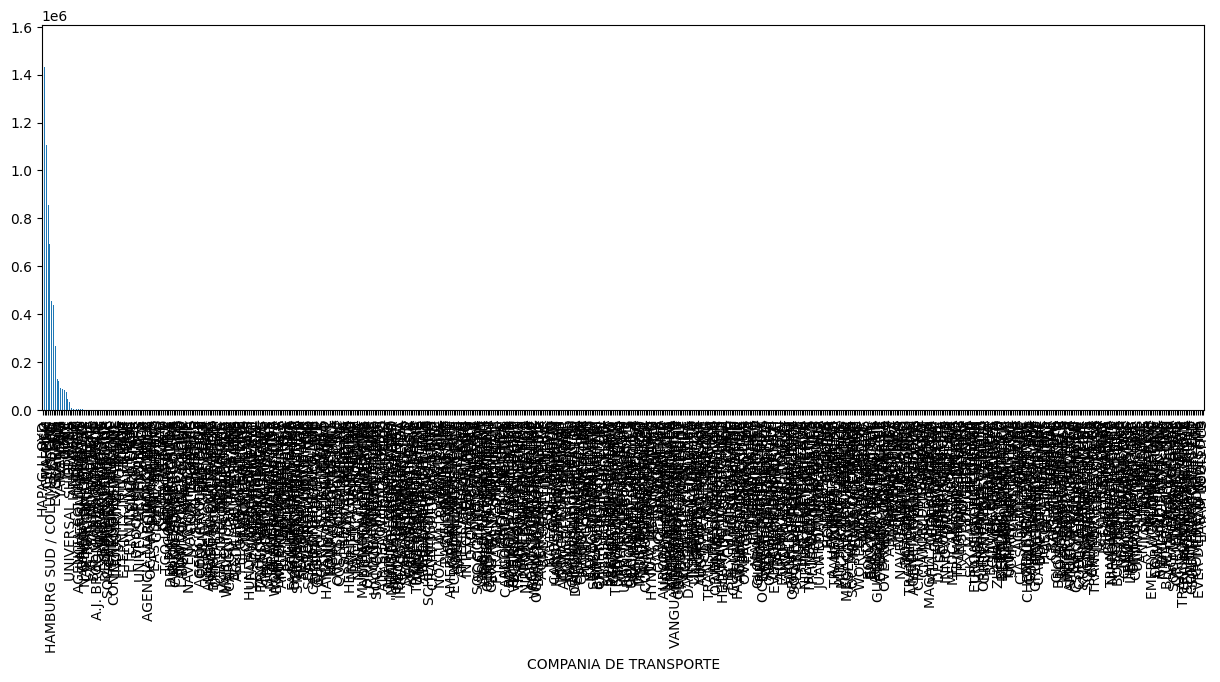

In [244]:
df["COMPANIA DE TRANSPORTE"].value_counts().plot(kind="bar", figsize=(15, 5))

<Axes: xlabel='COMPANIA DE TRANSPORTE'>

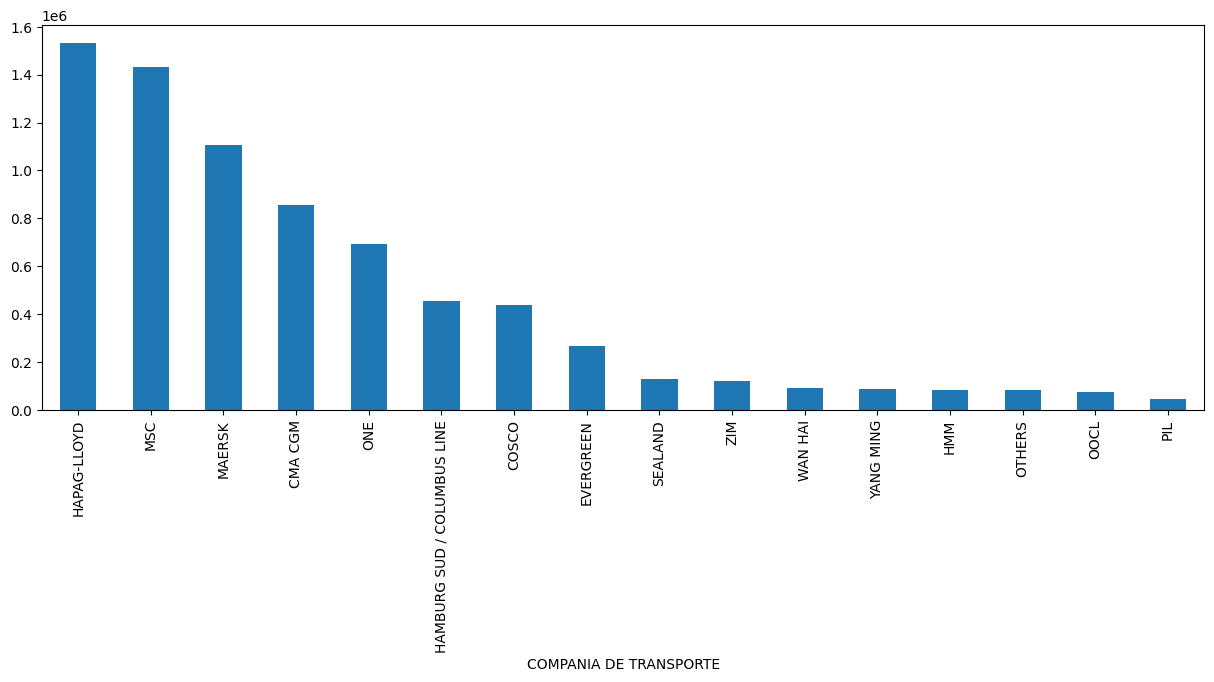

In [245]:
frecuencias = df["COMPANIA DE TRANSPORTE"].value_counts(normalize=True) * 100

# Identificar los que representan menos del 0.5%
menos_frecuentes = frecuencias[frecuencias < 0.5].index
df["COMPANIA DE TRANSPORTE"] = np.where(
    df["COMPANIA DE TRANSPORTE"].isin(menos_frecuentes),
    "OTHERS",
    df["COMPANIA DE TRANSPORTE"],
)
df["COMPANIA DE TRANSPORTE"] = np.where(
    df["COMPANIA DE TRANSPORTE"] == "NO EXISTE", "OTHER_COMP", df["COMPANIA DE TRANSPORTE"]
)
df["COMPANIA DE TRANSPORTE"].value_counts().plot(kind="bar", figsize=(15, 5))

In [246]:
df["TIPO DE BULTO"].value_counts()
df["TIPO DE BULTO"] = df["TIPO DE BULTO"].map(
    {
        "CONTENEDOR 40": 0,
        "CONTENEDOR 20": 0,
        "CONTENEDOR NO REFRIGERADO": 0,
        "CONTENEDOR REFRIGERADO 40": 2,
        "CONTENEDOR REFRIGERADO 20": 1,
    }
)
container_type_container_count = (
    df.groupby("FECHA")["TIPO DE BULTO"].sum().reset_index()
)
container_type_container_count

,FECHA,TIPO DE BULTO
0,2000-07,0
1,2000-23,0
2,2000-26,0
3,2000-36,0
4,2000-52,6
...,...,...
518,2024-48,620
519,2024-49,616
520,2024-50,633
521,2024-51,204


In [247]:
df["PAIS DE ORIGEN"].value_counts()

PAIS DE ORIGEN
CHINA                                       3539422
U.S.A                                        673565
ALEMANIA                                     330504
ORIGEN O DESTINO NO PRECISADO                328243
MEXICO                                       257097
                                             ...   
LIBERIA                                           1
GUYANA                                            1
TERRITORIO BRITANICO EN RESTO DE AMERICA          1
GIBRALTAR                                         1
SAN VICENTE                                       1
Name: count, Length: 171, dtype: int64

In [248]:
frecuencias = df["PAIS DE ORIGEN"].value_counts(normalize=True) * 100

# Identificar los que representan menos del 0.5%
menos_frecuentes = frecuencias[frecuencias < 1.5].index
df2 = df.copy()
df["PAIS DE ORIGEN"] = np.where(
    df["PAIS DE ORIGEN"].isin(menos_frecuentes), "OTHER_COUNTRIES", df["PAIS DE ORIGEN"]
)
print(df["PAIS DE ORIGEN"].nunique())
country_counts = df["PAIS DE ORIGEN"].value_counts()
country_counts

13


PAIS DE ORIGEN
CHINA                            3539422
OTHER_COUNTRIES                  1210265
U.S.A                             673565
ALEMANIA                          330504
ORIGEN O DESTINO NO PRECISADO     328243
MEXICO                            257097
ESPANA                            246081
FRANCIA                           206044
ITALIA                            197482
COLOMBIA                          136953
VIETNAM                           124092
INDIA                             122082
PERU                              113517
Name: count, dtype: int64

In [249]:
clausula_container_count = (
    df.groupby(["FECHA", "CLAUSULA"])["CANTIDAD DE BULTO"].sum().reset_index()
)
pivot_clausula_count = (
    clausula_container_count.pivot(
        index="FECHA", columns="CLAUSULA", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
price_per_coast_count = (
    df.groupby(["FECHA", "coast"])["FLETE_POR_BULTO"]
    .mean()
    .reset_index()
)
price_per_coast_count = price_per_coast_count.pivot(
    index="FECHA", columns="coast", values="FLETE_POR_BULTO"
).interpolate(method='linear', limit_direction='both')

company_container_count = (
    df.groupby(["FECHA", "COMPANIA DE TRANSPORTE"])["CANTIDAD DE BULTO"]
    .sum()
    .reset_index()
)
pivot_company_count = (
    company_container_count.pivot(
        index="FECHA", columns="COMPANIA DE TRANSPORTE", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
container_country_count = (
    df.groupby(["FECHA", "PAIS DE ORIGEN"])["CANTIDAD DE BULTO"].sum().reset_index()
)
pivot_country_count = (
    container_country_count.pivot(
        index="FECHA", columns="PAIS DE ORIGEN", values="CANTIDAD DE BULTO"
    )
    .fillna(0)
    .reset_index()
)
pivot_country_count

PAIS DE ORIGEN,FECHA,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHER_COUNTRIES,PERU,U.S.A,VIETNAM
0,2000-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
1,2000-23,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0
3,2000-36,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2000-52,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,2024-48,237.0,323.0,325.0,90.0,149.0,0.0,22.0,961.0,219.0,1830.0,460.0,1274.0,86.0
519,2024-49,79.0,3426.0,1344.0,124.0,71.0,15.0,14.0,848.0,179.0,1387.0,742.0,1405.0,82.0
520,2024-50,32.0,2891.0,2173.0,32.0,90.0,0.0,52.0,57.0,12.0,1224.0,1435.0,172.0,0.0
521,2024-51,30.0,213.0,746.0,8.0,0.0,0.0,10.0,0.0,12.0,300.0,993.0,71.0,38.0


In [250]:
weekly_df.head()

,FECHA
0,2000-07
1,2000-23
2,2000-26
3,2000-36
4,2000-52


In [251]:
quantity_daily = df.groupby("FECHA")["CANTIDAD DE BULTO"].sum().reset_index()
rut_diario = df.groupby("FECHA")["RUT PROBABLE IMPORTADOR"].nunique().reset_index()
rut_diario.rename(
    columns={"RUT PROBABLE IMPORTADOR": "RUTS_UNICOS_DIARIOS"}, inplace=True
)
weekly_df = pd.merge(weekly_df, rut_diario, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, pivot_clausula_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, pivot_company_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, quantity_daily, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, container_type_container_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, pivot_country_count, how="outer", on="FECHA")
weekly_df = pd.merge(weekly_df, price_per_coast_count, how="outer", on="FECHA")

cols = [
    "DIFF_DAYS",
    "FOB_POR_BULTO",
    "SEGURO_POR_BULTO",
    "FLETE_POR_BULTO",
    "PESO BRUTO POR CONTENEDOR",
    "ITEMS POR CONTENEDOR",
]
agg_funcs = ["mean", "max", "std"]

for col in cols:
    agg_df = df.groupby("FECHA")[col].agg(agg_funcs).reset_index()
    agg_df.columns = ["FECHA"] + [f"{func.upper()}_{col}" for func in agg_funcs]
    weekly_df = pd.merge(weekly_df, agg_df, how="outer", on="FECHA")
weekly_df = weekly_df.drop(0).reset_index(drop=True)

In [252]:
original_columns = set(weekly_df.columns)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7485347 entries, 0 to 7488895
Data columns (total 20 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   NUMERO DE ACEPTACION       int64  
 1   RUT PROBABLE IMPORTADOR    object 
 2   PAIS DE ORIGEN             object 
 3   PUERTO DE EMBARQUE         object 
 4   PUERTO DE DESEMBARQUE      object 
 5   COMPANIA DE TRANSPORTE     object 
 6   TIPO DE BULTO              int64  
 7   CLAUSULA                   object 
 8   CANTIDAD DE BULTO          int64  
 9   CANTIDAD UNIDADES FISICAS  float64
 10  UNIDAD DE MEDIDA FISICA    object 
 11  FECHA_TRANS                object 
 12  DIFF_DAYS                  float64
 13  FOB_POR_BULTO              float64
 14  FLETE_POR_BULTO            float64
 15  SEGURO_POR_BULTO           float64
 16  PESO BRUTO POR CONTENEDOR  float64
 17  ITEMS POR CONTENEDOR       float64
 18  FECHA                      object 
 19  coast                      object 
dtypes: floa

In [253]:
weekly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   FECHA                           523 non-null    object 
 1   RUTS_UNICOS_DIARIOS             522 non-null    float64
 2   CD                              522 non-null    float64
 3   CFR                             522 non-null    float64
 4   F                               522 non-null    float64
 5   OTRO                            522 non-null    float64
 6   CMA CGM                         522 non-null    float64
 7   COSCO                           522 non-null    float64
 8   EVERGREEN                       522 non-null    float64
 9   HAMBURG SUD / COLUMBUS LINE     522 non-null    float64
 10  HAPAG-LLOYD                     522 non-null    float64
 11  HMM                             522 non-null    float64
 12  MAERSK                          522 

In [254]:
folder = "../data/macro"
for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        df_macro = pd.read_csv(file_path)

        if "Date" in df_macro.columns:
            df_macro["FECHA"] = pd.to_datetime(df_macro["Date"], errors="coerce")
            df_macro["FECHA_WEEK"] = df_macro["FECHA"].dt.strftime("%Y-%U")
            df_macro = df_macro.sort_values("FECHA").drop(columns=["Date"])
            df_macro[["Close", "Volume"]] = (
                df_macro[["Close", "Volume"]]
                .fillna(method="ffill")
                .fillna(method="bfill")
            )
            df_macro["Close_pct_change"] = df_macro["Close"].pct_change().fillna(0)

            # df_macro.to_csv("test_macro.csv", index=False)

            if "Close" in df_macro.columns and "Volume" in df_macro.columns:
                df_macro[["Close", "Volume"]] = df_macro[["Close", "Volume"]].fillna(
                    method="ffill"
                )
                df_macro = (
                    df_macro.groupby("FECHA_WEEK")
                    .agg(
                        {
                            "Close": "last",
                            "Volume": "sum",
                        }
                    )
                    .reset_index()
                )
                df_macro["Close_pct_change"] = df_macro["Close"].pct_change().fillna(0)
                name = filename.replace(".csv", "").lower()  # e.g. 'data_gold'
                macro_filtered = df_macro[
                    ["FECHA_WEEK", "Close", "Volume", "Close_pct_change"]
                ].rename(
                    columns={
                        "FECHA_WEEK": "FECHA",
                        "Close": f"{name}_price",
                        "Volume": f"{name}_volume",
                        "Close_pct_change": f"{name}_pct_change",
                    }
                )

                weekly_df = pd.merge(weekly_df, macro_filtered, how="left", on="FECHA")

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_69610/3353069615.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[["Close", "Volume"]]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_69610/3353069615.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[["Close", "Volume"]] = df_macro[["Close", "Volume"]].fillna(
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_69610/3353069615.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_macro[["Close", "Volume"]]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_69610/3353069615.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill

In [255]:
new_columns = [col for col in weekly_df.columns if col not in original_columns]
weekly_df[new_columns] = (
    weekly_df[new_columns].fillna(method="ffill").fillna(method="bfill")
)
weekly_df

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_69610/2674497027.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weekly_df[new_columns].fillna(method="ffill").fillna(method="bfill")


,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHER_COUNTRIES,PERU,U.S.A,VIETNAM,FE,IND,NAE,NAW,NE,SAE,SAW,SE,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR,wan_hai_price,wan_hai_volume,wan_hai_pct_change,data_gold_price,data_gold_volume,data_gold_pct_change,zim_price,zim_volume,zim_pct_change,sea_price,sea_volume,sea_pct_change,ipsa_price,ipsa_volume,ipsa_pct_change,cny_price,cny_volume,cny_pct_change,clp_price,clp_volume,clp_pct_change,wti_oil_price,wti_oil_volume,wti_oil_pct_change,csi300_price,csi300_volume,csi300_pct_change,brent_oil_price,brent_oil_volume,brent_oil_pct_change,maersk_price,maersk_volume,maersk_pct_change,hapag_price,hapag_volume,hapag_pct_change,yang_ming_price,yang_ming_volume,yang_ming_pct_change,cosco_shipping_price,cosco_shipping_volume,cosco_shipping_pct_change,boat_price,boat_volume,boat_pct_change,sp500_price,sp500_volume,sp500_pct_change
0,2000-23,1.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18615.000000,2068.633333,2829.000000,4546.571429,1303.140000,6798.690000,2700.000000,2546.775000,8077.000000,8077.0,0.000000,133841.000000,133841.000,0.000000,160.610000,160.610,0.000000,18615.000000,18615.000,0.000000,88481.000000,88481.00,0.000000,7.000000,7.0,0.000000,6.312423,10443486.0,-0.022140,273.299988,127.0,-0.013357,12.050000,7824600.0,0.000000,19.414,13200.0,0.000000,1154.160034,0.0,-0.040901,8.2770,0.0,0.000036,597.260010,0.0,0.026679,33.700001,338803.0,0.009587,5146.379883,390600.0,0.000000,113.330002,6717.0,-0.087373,7243.132324,4626.0,0.005036,19.191978,69868.0,-0.036504,24.048120,44537021.0,-0.078534,2.461538,41902331.0,-0.007752,25.155001,15400.0,0.000000,1456.949951,4.283600e+09,-0.013748
1,2000-26,1.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,10532.500000,2068.633333,2829.000000,4546.571429,1303.140000,6798.690000,2700.000000,2546.775000,8070.000000,8070.0,0.000000,91806.400000,91806.400,0.000000,495.750000,495.750,0.000000,2829.000000,2829.000,0.000000,1697.000000,1697.00,0.000000,14.000000,14.0,0.000000,5.931297,10992308.0,-0.031128,273.299988,127.0,-0.013357,12.050000,7824600.0,0.000000,19.414,13200.0,0.000000,1154.160034,0.0,-0.040901,8.2770,0.0,0.000036,597.260010,0.0,0.026679,33.700001,338803.0,0.009587,5146.379883,390600.0,0.000000,113.330002,6717.0,-0.087373,6712.819336,11405.0,-0.028862,19.191978,69868.0,-0.036504,23.091648,11382115.0,0.024242,2.461538,41902331.0,-0.007752,25.155001,15400.0,0.000000,1454.599976,5.597200e+09,0.009102
2,2000-36,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2450.000000,2068.633333,3105.571429,4546.571429,1303.140000,6798.690000,2700.000000,2546.775000,8080.000000,8080.0,NaN,11273.750000,11273.750,NaN,75.000000,75.000,NaN,2450.000000,2450.000,NaN,6332.050000,6332.05,NaN,0.500000,0.5,NaN,5.659741,6820108.0,0.031249,273.299988,127.0,-0.013357,12.050000,7824600.0,0.000000,19.414,13200.0,0.000000,1154.160034,0.0,-0.040901,8.2770,0.0,0.000036,597.260010,0.0,0.026679,33.700001,338803.0,0.009587,5146.379883,390600.0,0.000000,113.330002,6717.0,-0.087373,8363.417969,14742.0,0.046546,19.191978,69868.0,-0.036504,18.269520,10281337.0,0.048458,2.461538,41902331.0,-0.007752,25.155001,15400.0,0.00

In [256]:
weekly_df = weekly_df[weekly_df['FECHA'] >= '2020-01']
weekly_df.to_csv("../proc/weekly_price_data_kz.csv", index=False)

In [257]:
folder = "../data/bloom"
bloom_list = []

for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        df = pd.read_csv(file_path)

        if "Date" in df.columns:
            # Parse date and create weekly key
            df["FECHA"] = pd.to_datetime(df["Date"], errors="coerce")
            df["FECHA_WEEK"] = df["FECHA"].dt.strftime("%Y-%U")

            # Sort by date and drop original Date col
            df = df.sort_values("FECHA", kind="mergesort").drop(columns=["Date"])

            # Work ONLY on numeric columns
            value_cols = df.select_dtypes(include="number").columns.tolist()

            # Fill numeric gaps
            df[value_cols] = df[value_cols].ffill().bfill()

            # Aggregate to weekly (take last observation in each week)
            df_week = df.groupby("FECHA_WEEK", as_index=False).last()

            # Weekly pct change per numeric column
            for col in value_cols:
                df_week[f"Close_pct_change_{col}"] = df_week[col].pct_change().fillna(0)

            # Final column order
            out_cols = (
                ["FECHA_WEEK"]
                + value_cols
                + [f"Close_pct_change_{c}" for c in value_cols]
            )
            macro_filtered = df_week[out_cols].rename(columns={"FECHA_WEEK": "FECHA"})

            bloom_list.append(macro_filtered)

bloom_list[0]

,FECHA,XSICFEUW Index (R4),XSICFENE Index (R1),XSICFESE Index (L4),XSICNEFE Index (R2),XSICNESE Index (L2),XSICUENE Index (R1),XSICUWFE Index (L1),XSICNEUE Index (L3),BDIY Index (R3),Close_pct_change_XSICFEUW Index (R4),Close_pct_change_XSICFENE Index (R1),Close_pct_change_XSICFESE Index (L4),Close_pct_change_XSICNEFE Index (R2),Close_pct_change_XSICNESE Index (L2),Close_pct_change_XSICUENE Index (R1),Close_pct_change_XSICUWFE Index (L1),Close_pct_change_XSICNEUE Index (L3),Close_pct_change_BDIY Index (R3)
0,2020-30,2681.0,1593.0,650.0,1437.0,1060.0,537.0,654.0,1925.0,1350.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2020-31,3097.0,1645.0,1189.0,1405.0,1040.0,479.0,633.0,1895.0,1501.0,0.155166,0.032643,0.829231,-0.022269,-0.018868,-0.108007,-0.032110,-0.015584,0.111852
2,2020-32,3069.0,1695.0,1173.0,1402.0,1054.0,464.0,633.0,1895.0,1595.0,-0.009041,0.030395,-0.013457,-0.002135,0.013462,-0.031315,0.000000,0.000000,0.062625
3,2020-33,3232.0,1742.0,1506.0,1397.0,1049.0,491.0,648.0,1884.0,1481.0,0.053112,0.027729,0.283887,-0.003566,-0.004744,0.058190,0.023697,-0.005805,-0.071473
4,2020-34,3349.0,1737.0,1567.0,1393.0,1058.0,513.0,656.0,1884.0,1488.0,0.036200,-0.002870,0.040505,-0.002863,0.008580,0.044807,0.012346,0.000000,0.004727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,2025-29,2206.0,3410.0,6199.0,234.0,622.0,647.0,634.0,1990.0,2257.0,-0.016496,-0.002341,-0.094904,-0.008475,-0.003205,-0.025602,-0.010920,-0.006986,0.099903
262,2025-30,2166.0,3362.0,5108.0,237.0,637.0,627.0,638.0,2013.0,2018.0,-0.018132,-0.014076,-0.175996,0.012821,0.024116,-0.030912,0.006309,0.011558,-0.105893
263,2025-31,1979.0,3291.0,4761.0,226.0,638.0,637.0,632.0,1956.0,2051.0,-0.086334,-0.021118,-0.067933,-0.046414,0.001570,0.015949,-0.009404,-0.028316,0.016353
264,2025-32,1862.0,3119.0,3840.0,214.0,617.0,638.0,632.0,1954.0,2044.0,-0.059121,-0.052264,-0.193447,-0.053097,-0.032915,0.001570,0.000000,-0.001022,-0.003413


In [258]:
bloom_list[0].to_csv("../data/proc/test_bloom_kz.csv", index=False)

In [260]:
final_df = weekly_df.copy()
final_df = pd.merge(final_df, bloom_list[0], how="outer", on="FECHA")
# drop rows with any NaN values
final_df = final_df.dropna(how="any").reset_index(drop=True)
final_df

,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHER_COUNTRIES,PERU,U.S.A,VIETNAM,FE,IND,NAE,NAW,NE,SAE,SAW,SE,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR,wan_hai_price,wan_hai_volume,wan_hai_pct_change,data_gold_price,data_gold_volume,data_gold_pct_change,zim_price,zim_volume,zim_pct_change,sea_price,sea_volume,sea_pct_change,ipsa_price,ipsa_volume,ipsa_pct_change,cny_price,cny_volume,cny_pct_change,clp_price,clp_volume,clp_pct_change,wti_oil_price,wti_oil_volume,wti_oil_pct_change,csi300_price,csi300_volume,csi300_pct_change,brent_oil_price,brent_oil_volume,brent_oil_pct_change,maersk_price,maersk_volume,maersk_pct_change,hapag_price,hapag_volume,hapag_pct_change,yang_ming_price,yang_ming_volume,yang_ming_pct_change,cosco_shipping_price,cosco_shipping_volume,cosco_shipping_pct_change,boat_price,boat_volume,boat_pct_change,sp500_price,sp500_volume,sp500_pct_change,XSICFEUW Index (R4),XSICFENE Index (R1),XSICFESE Index (L4),XSICNEFE Index (R2),XSICNESE Index (L2),XSICUENE Index (R1),XSICUWFE Index (L1),XSICNEUE Index (L3),BDIY Index (R3),Close_pct_change_XSICFEUW Index (R4),Close_pct_change_XSICFENE Index (R1),Close_pct_change_XSICFESE Index (L4),Close_pct_change_XSICNEFE Index (R2),Close_pct_change_XSICNESE Index (L2),Close_pct_change_XSICUENE Index (R1),Close_pct_change_XSICUWFE Index (L1),Close_pct_change_XSICNEUE Index (L3),Close_pct_change_BDIY Index (R3)
0,2020-30,3.0,5.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,6568.500000,3700.621667,3684.795357,1390.591667,898.500000,4957.473684,16.250000,1258.817500,651.800000,1518.0,527.134423,71745.282000,261458.810,107032.191364,1082.960000,5229.180,2317.921973,2990.050000,7712.000,3384.466079,9064.800000,12322.0,4266.684099,0.900000,1.0,0.223607,13.754940,8208672.0,-0.005714,1962.800049,242791.0,0.034523,12.050000,7824600.0,0.000000,19.414,13200.0,0.000000,5058.879883,0.0,0.0,7.0073,0.0,0.000600,761.000000,0.0,-0.011560,40.270000,1756486.0,-0.024703,5146.379883,390600.0,0.000000,43.299999,83260.0,-0.000923,8076.0,87860.0,-0.037426,46.400002,120145.0,-0.050153,6.310000,9683547.0,0.009600,2.246153,101068929.0,0.081481,25.155001,15400.0,0.000000,3271.120117,2.177414e+10,0.017256,2681.0,1593.0,650.0,1437.0,1060.0,537.0,654.0,1925.0,1350.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2020-31,5.0,10.0,0.0,37.0,1.0,0.0,5.0,0.0,2.0,6.0,0.0,7.0,4.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,8.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,33.0,0.0,0.0,0.0,6250.000000,3487.292083,4097.397679,1286.810000,4630.636364,5410.552632,2064.911765,650.000000,473.812500,1154.0,355.272584,17797.612969,76500.000,13644.447436,209.662969,335.000,128.508849,3139.915937,10649.920,3465.751919,23526.296875,102000.0,31804.837504,3.843750,6.0,2.005788,14.466403,13892966.0,0.051724,2010.099976,5217.0,0.024098,12.050000,7824600.0,0.000000,19.414,13200.0,0.000000,5058.879883,0.0,0.0,6.9524,0.0,-0.007835,773.000000,0.0,0.015769,41.220001,2039776.0,0.023591,5146.379883,390600.0,0.000000,44.400002,127019.0,0.025404,8750.0,96177.0,0.083457,47.349998,141658.0,0.020474,6.460000,11750692.0,0.023772,2.523076,186265371.0,0.123288,25.155001,15400.0,0.000000,3351.280029,2.177734e+10,0.024505,3097.0,1645.0,1189.0,1405.0,1040.0,479.0,633.0,1895.0,1501.0,0.155166,0.032643,0.829231,-0.022269,-0.018868,-0.108007,-0.032110,-0.015584,

In [261]:
final_df.to_csv("../data/proc/test_final_kz.csv", index=False)

In [144]:
final_df[country_counts.index.to_list()+['MEAN_FLETE_POR_BULTO']]

,CHINA,OTHER_COUNTRIES,U.S.A,ALEMANIA,ORIGEN O DESTINO NO PRECISADO,MEXICO,ESPANA,FRANCIA,ITALIA,COLOMBIA,VIETNAM,INDIA,PERU,MEAN_FLETE_POR_BULTO
0,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2990.050000
1,8.0,33.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,2.0,0.0,3139.915937
2,36.0,2.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5007.193068
3,5.0,22.0,0.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0,0.0,20.0,6.0,1742.712868
4,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,586.507500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,323.0,1830.0,1274.0,237.0,219.0,961.0,90.0,149.0,22.0,325.0,86.0,0.0,460.0,2347.606757
228,3426.0,1387.0,1405.0,79.0,179.0,848.0,124.0,71.0,14.0,1344.0,82.0,15.0,742.0,1359.523705
229,2891.0,1224.0,172.0,32.0,12.0,57.0,32.0,90.0,52.0,2173.0,0.0,0.0,1435.0,1073.435397
230,213.0,300.0,71.0,30.0,12.0,0.0,8.0,0.0,10.0,746.0,38.0,0.0,993.0,2211.844948


In [222]:
df = df[df['PAIS DE ORIGEN'] != 'OTHER_COUNTRIES']
df = df[df['PAIS DE ORIGEN'] != 'ORIGEN O DESTINO NO PRECISADO']
country_price_stats = df.groupby("PAIS DE ORIGEN")["FLETE_POR_BULTO"].agg([
    'mean', 'median', 'std', 'count'
]).reset_index()
country_price_stats = country_price_stats[country_price_stats['PAIS DE ORIGEN'] != 'OTHER_COUNTRIES']
country_price_stats

,PAIS DE ORIGEN,mean,median,std,count
0,ALEMANIA,2496.897773,1551.905,5188.337963,330504
1,CHINA,4418.744489,2500.000,9449.376338,3539422
2,COLOMBIA,1804.830513,956.500,2855.842365,136953
3,ESPANA,4132.030192,2414.540,6948.700914,246081
4,FRANCIA,2236.884384,1448.745,3909.963713,206044
5,INDIA,4065.571585,2157.800,7526.168383,122082
6,ITALIA,3705.026985,2298.310,6192.400150,197482
7,MEXICO,2536.347863,1229.065,4948.148278,257097
8,PERU,1859.124426,880.155,3365.077255,113517
9,U.S.A,2191.115753,1353.810,3605.747286,673565


In [223]:
country_price_stats.columns = ['PAIS_DE_ORIGEN', 'MEAN_FLETE_POR_BULTO', 'MEDIAN_FLETE_POR_BULTO', 'STD_FLETE_POR_BULTO', 'COUNT_RECORDS']
country_price_stats_sorted = country_price_stats.sort_values('MEAN_FLETE_POR_BULTO', ascending=False)
print("Mean Freight Price by Country:")
print(country_price_stats_sorted)
print(f"\nNumber of countries: {len(country_price_stats_sorted)}")

Mean Freight Price by Country:
   PAIS_DE_ORIGEN  MEAN_FLETE_POR_BULTO  MEDIAN_FLETE_POR_BULTO  \
1           CHINA           4418.744489                2500.000   
10        VIETNAM           4416.296953                2081.205   
3          ESPANA           4132.030192                2414.540   
5           INDIA           4065.571585                2157.800   
6          ITALIA           3705.026985                2298.310   
7          MEXICO           2536.347863                1229.065   
0        ALEMANIA           2496.897773                1551.905   
4         FRANCIA           2236.884384                1448.745   
9           U.S.A           2191.115753                1353.810   
8            PERU           1859.124426                 880.155   
2        COLOMBIA           1804.830513                 956.500   

    STD_FLETE_POR_BULTO  COUNT_RECORDS  
1           9449.376338        3539422  
10          7977.383840         124092  
3           6948.700914         246081  


/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_69610/2828599022.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax2.boxplot(data_for_boxplot, labels=countries_for_boxplot, patch_artist=True)


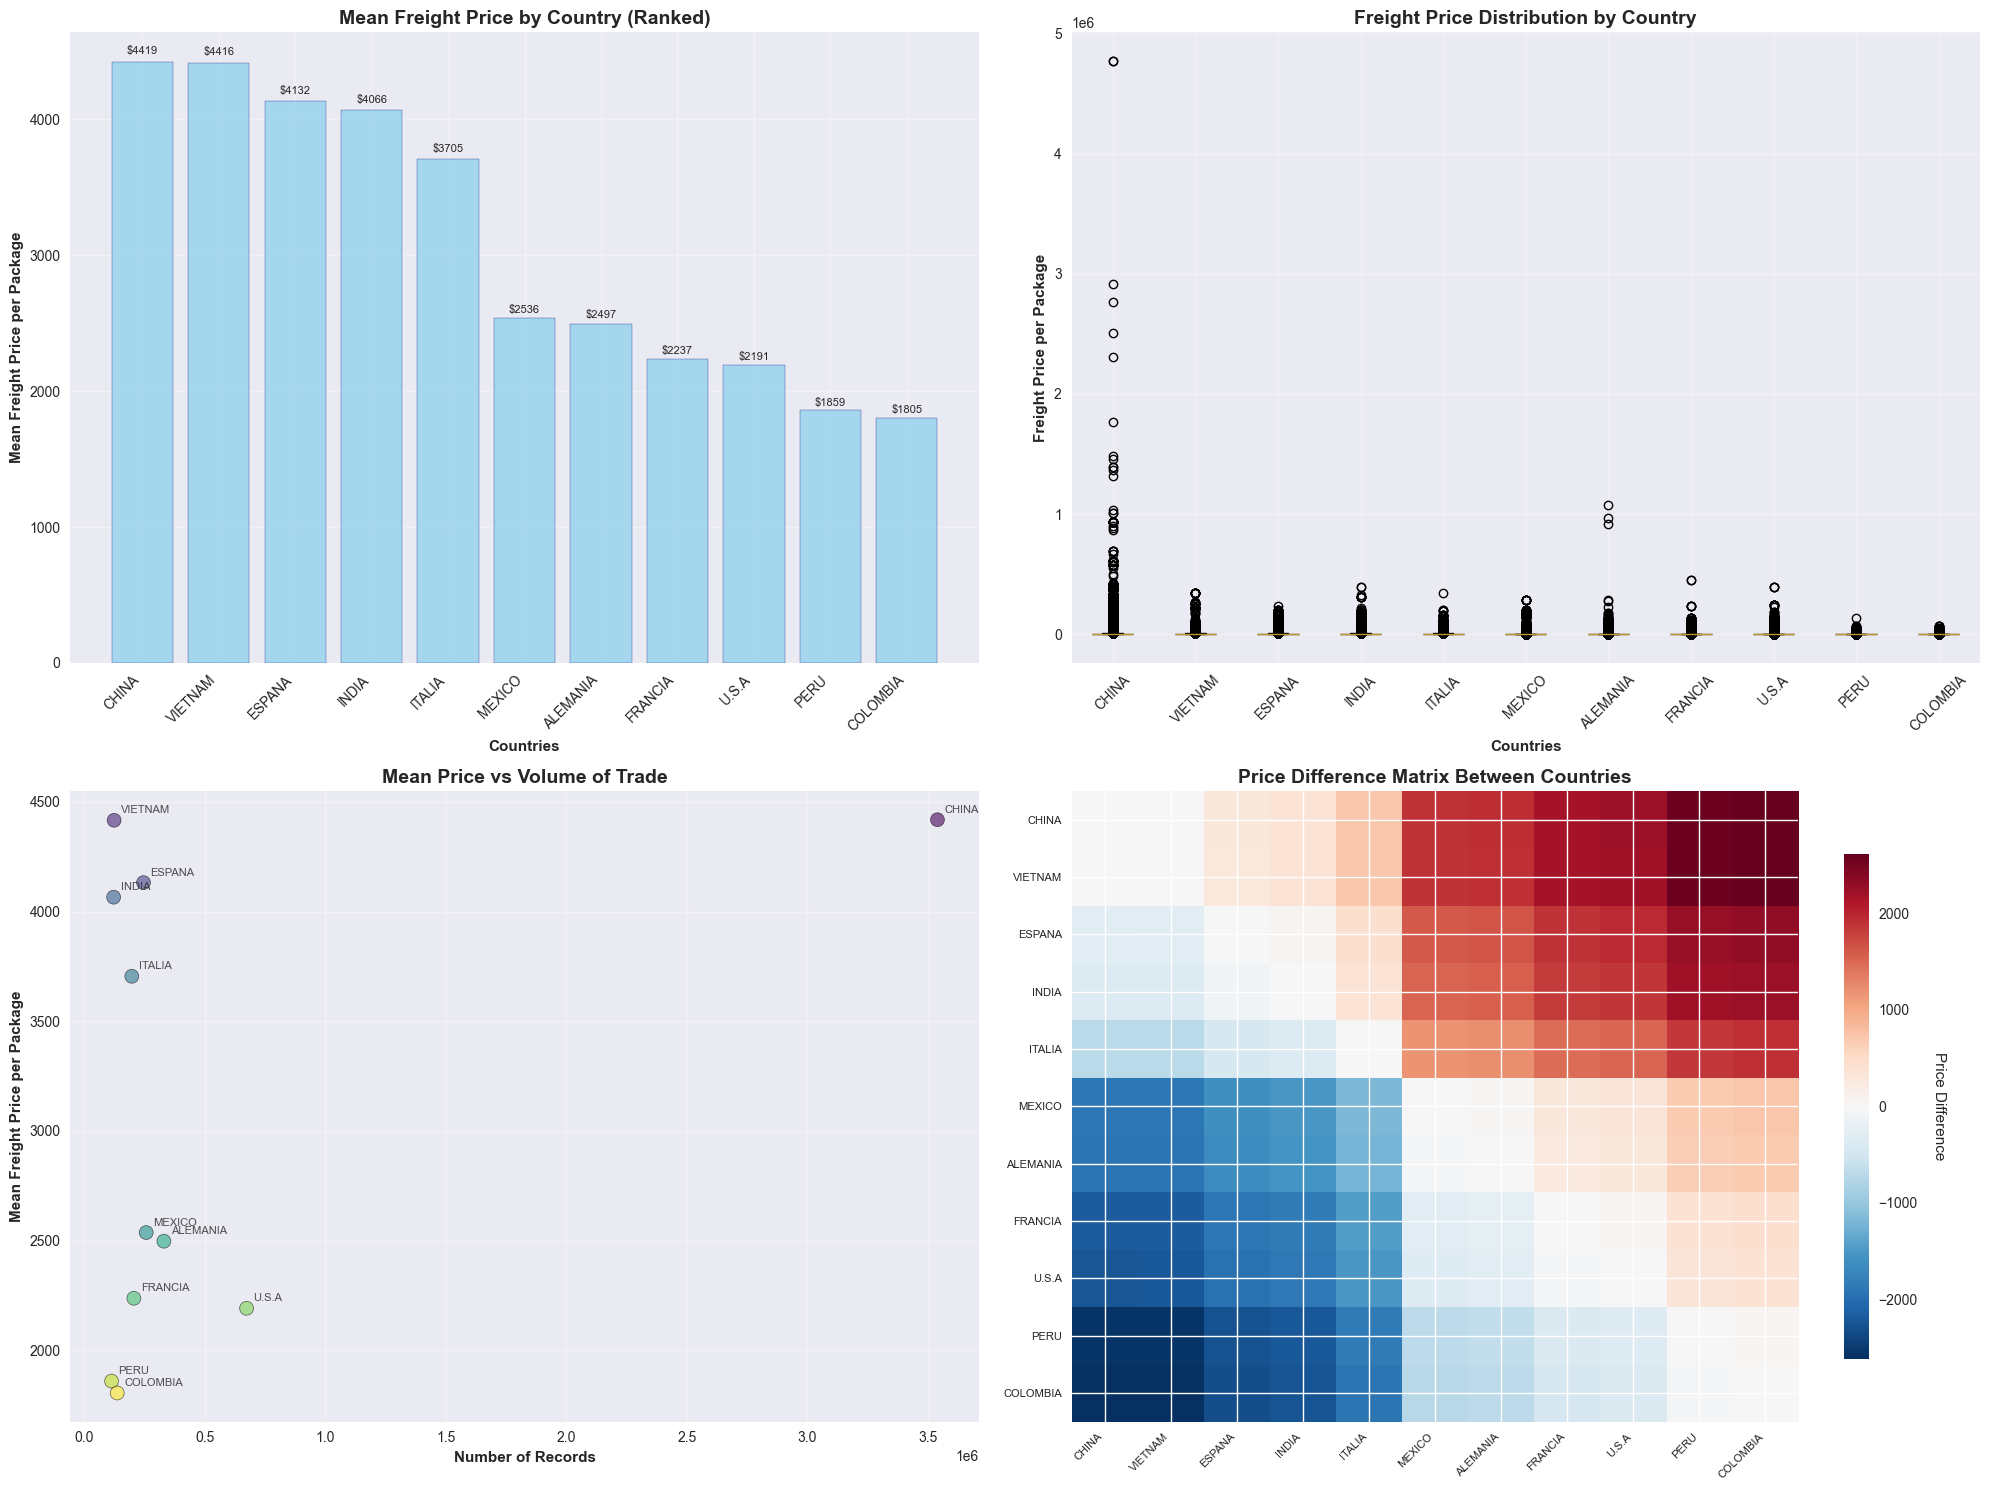

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. Bar plot of mean prices by country
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Bar plot
ax1 = axes[0, 0]
bars = ax1.bar(range(len(country_price_stats_sorted)),
               country_price_stats_sorted['MEAN_FLETE_POR_BULTO'],
               color='skyblue', edgecolor='navy', alpha=0.7)
ax1.set_xlabel('Countries', fontweight='bold')
ax1.set_ylabel('Mean Freight Price per Package', fontweight='bold')
ax1.set_title('Mean Freight Price by Country (Ranked)', fontweight='bold', fontsize=14)
ax1.set_xticks(range(len(country_price_stats_sorted)))
ax1.set_xticklabels(country_price_stats_sorted['PAIS_DE_ORIGEN'], rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height:.0f}', ha='center', va='bottom', fontsize=8)

# 2. Box plot to show distribution patterns
ax2 = axes[0, 1]
countries_for_boxplot = country_price_stats_sorted['PAIS_DE_ORIGEN'].tolist()
data_for_boxplot = [df[df['PAIS DE ORIGEN'] == country]['FLETE_POR_BULTO'].dropna()
                    for country in countries_for_boxplot]

box_plot = ax2.boxplot(data_for_boxplot, labels=countries_for_boxplot, patch_artist=True)
ax2.set_xlabel('Countries', fontweight='bold')
ax2.set_ylabel('Freight Price per Package', fontweight='bold')
ax2.set_title('Freight Price Distribution by Country', fontweight='bold', fontsize=14)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(box_plot['boxes'])))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 3. Scatter plot: Mean Price vs Number of Records
ax3 = axes[1, 0]
scatter = ax3.scatter(country_price_stats_sorted['COUNT_RECORDS'],
                     country_price_stats_sorted['MEAN_FLETE_POR_BULTO'],
                     s=100, alpha=0.6, c=range(len(country_price_stats_sorted)),
                     cmap='viridis', edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Number of Records', fontweight='bold')
ax3.set_ylabel('Mean Freight Price per Package', fontweight='bold')
ax3.set_title('Mean Price vs Volume of Trade', fontweight='bold', fontsize=14)
ax3.grid(True, alpha=0.3)

# Add country labels to scatter points
for i, country in enumerate(country_price_stats_sorted['PAIS_DE_ORIGEN']):
    ax3.annotate(country,
                (country_price_stats_sorted.iloc[i]['COUNT_RECORDS'],
                 country_price_stats_sorted.iloc[i]['MEAN_FLETE_POR_BULTO']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

# 4. Heatmap-style comparison matrix
ax4 = axes[1, 1]
# Create a price difference matrix
price_matrix = np.zeros((len(country_price_stats_sorted), len(country_price_stats_sorted)))
countries = country_price_stats_sorted['PAIS_DE_ORIGEN'].tolist()
prices = country_price_stats_sorted['MEAN_FLETE_POR_BULTO'].values

for i in range(len(prices)):
    for j in range(len(prices)):
        price_matrix[i][j] = prices[i] - prices[j]

im = ax4.imshow(price_matrix, cmap='RdBu_r', aspect='auto')
ax4.set_xticks(range(len(countries)))
ax4.set_yticks(range(len(countries)))
ax4.set_xticklabels(countries, rotation=45, ha='right', fontsize=8)
ax4.set_yticklabels(countries, fontsize=8)
ax4.set_title('Price Difference Matrix Between Countries', fontweight='bold', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax4, shrink=0.8)
cbar.set_label('Price Difference', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

In [225]:
country_price_timeseries = df.groupby(['FECHA', 'PAIS DE ORIGEN'])['FLETE_POR_BULTO'].agg([
    'mean', 'count', 'std'
]).reset_index()
country_price_timeseries = country_price_timeseries[country_price_timeseries['PAIS DE ORIGEN'] != 'OTHER_COUNTRIES']
country_price_timeseries.columns = ['FECHA', 'PAIS_DE_ORIGEN', 'MEAN_FLETE_POR_BULTO', 'COUNT_RECORDS', 'STD_FLETE_POR_BULTO']
country_price_timeseries['FECHA_DATETIME'] = pd.to_datetime(country_price_timeseries['FECHA'] + '-1', format='%Y-%U-%w')
country_price_timeseries['FECHA_DATETIME']
print("Checking for duplicates...")
duplicates = country_price_timeseries.groupby(['FECHA_DATETIME', 'PAIS_DE_ORIGEN']).size()
duplicate_entries = duplicates[duplicates > 1]
if len(duplicate_entries) > 0:
    print(f"Found {len(duplicate_entries)} duplicate date-country combinations. Aggregating...")
    print("Sample duplicates:")
    print(duplicate_entries.head())

    # Aggregate duplicates by taking the mean
    country_price_timeseries = country_price_timeseries.groupby(['FECHA_DATETIME', 'PAIS_DE_ORIGEN']).agg({
        'MEAN_FLETE_POR_BULTO': 'mean',
        'COUNT_RECORDS': 'sum',
        'STD_FLETE_POR_BULTO': 'mean',
        'FECHA': 'first'  # Keep the first FECHA value
    }).reset_index()
    print("Duplicates resolved.")
else:
    print("No duplicates found.")
countries = df['PAIS DE ORIGEN'].unique()
countries = [c for c in countries if c != 'OTHER_COUNTRIES']
main_countries = [c for c in countries if c != 'OTHER_COUNTRIES']
print(f"Countries to analyze: {main_countries}")
print(f"Total time periods: {country_price_timeseries['FECHA_DATETIME'].nunique()}")

# Create pivot table for easier plotting - now should work without duplicates
price_pivot = country_price_timeseries.pivot(index='FECHA_DATETIME', columns='PAIS_DE_ORIGEN', values='MEAN_FLETE_POR_BULTO')
print("\nTime series data shape:", price_pivot.shape)
print("Date range:", price_pivot.index.min(), "to", price_pivot.index.max())
price_pivot = price_pivot[price_pivot.index >= '2020-01-01']
country_price_timeseries = country_price_timeseries[country_price_timeseries['FECHA_DATETIME'] >= '2020-01-01']

Checking for duplicates...
Found 11 duplicate date-country combinations. Aggregating...
Sample duplicates:
FECHA_DATETIME  PAIS_DE_ORIGEN
2024-01-01      ALEMANIA          2
                CHINA             2
                COLOMBIA          2
                ESPANA            2
                FRANCIA           2
dtype: int64
Duplicates resolved.
Countries to analyze: ['VIETNAM', 'CHINA', 'COLOMBIA', 'PERU', 'ALEMANIA', 'U.S.A', 'MEXICO', 'ITALIA', 'ESPANA', 'FRANCIA', 'INDIA']
Total time periods: 487

Time series data shape: (487, 11)
Date range: 2000-06-05 00:00:00 to 2024-12-30 00:00:00


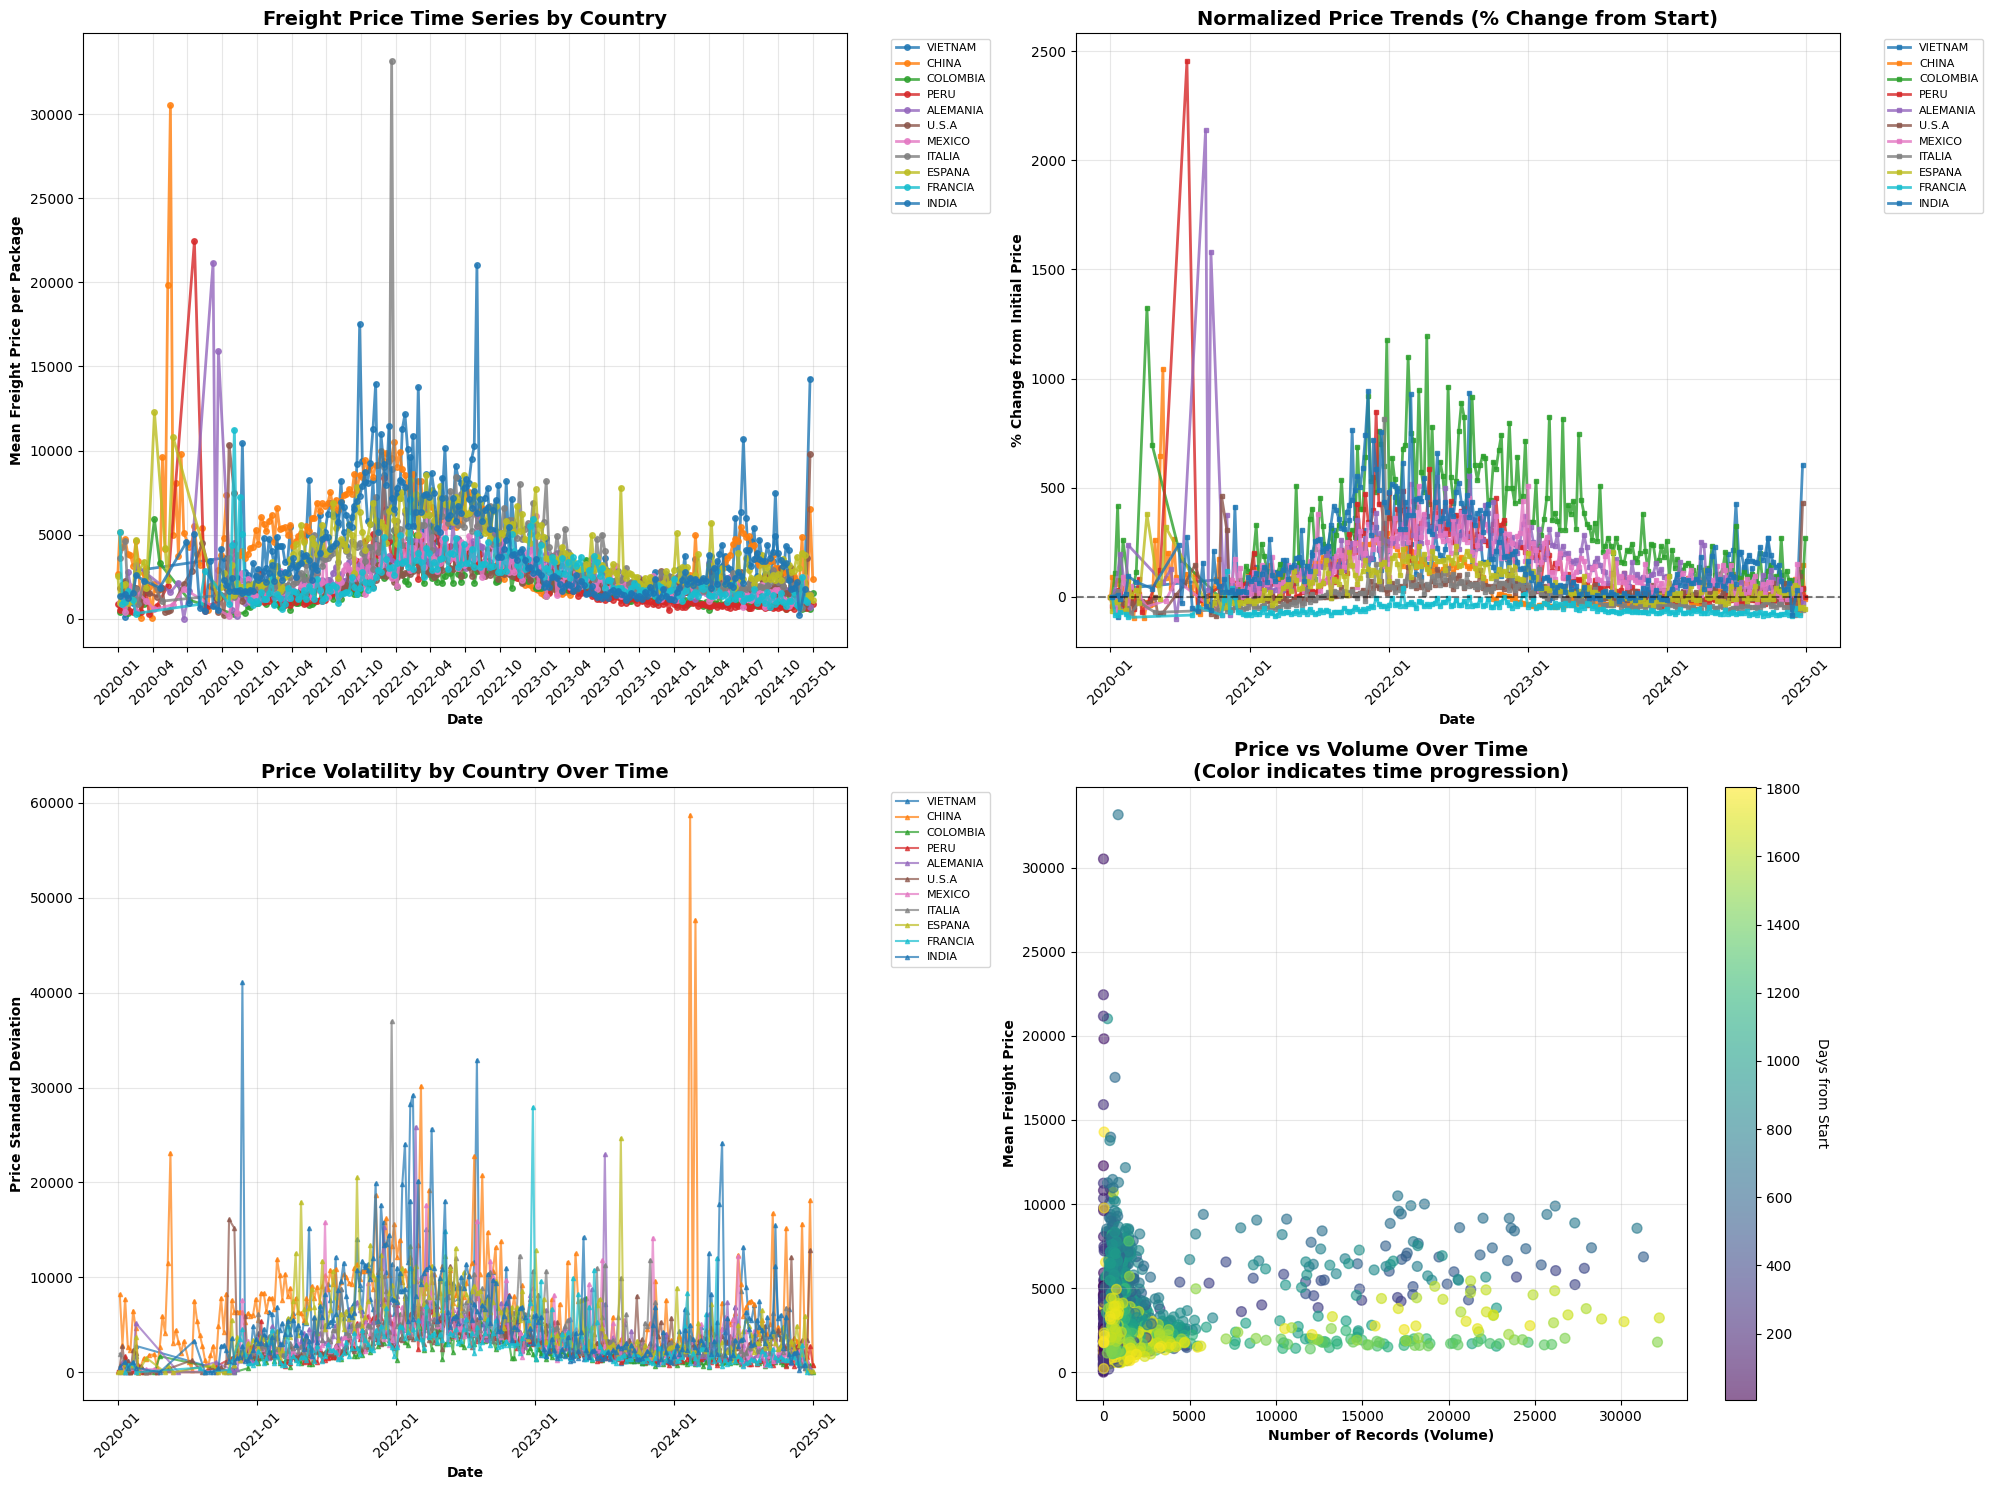

In [228]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime

# Set style for better plots
plt.style.use('default')
sns.set_palette("tab10")

# 1. Main comparison plot - all countries on one chart
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Plot 1: All countries time series
ax1 = axes[0, 0]
for country in main_countries:
    if country in price_pivot.columns:
        data = price_pivot[country].dropna()
        if len(data) > 3:  # Only plot countries with sufficient data points
            ax1.plot(data.index, data.values, marker='o', markersize=4,
                    linewidth=2, label=country, alpha=0.8)

ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Mean Freight Price per Package', fontweight='bold')
ax1.set_title('Freight Price Time Series by Country', fontweight='bold', fontsize=14)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Format x-axis dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Plot 2: Normalized trends (showing relative changes)
ax2 = axes[0, 1]
real_countries = [c for c in main_countries if c != 'ORIGEN O DESTINO NO PRECISADO']
for country in real_countries:
    if country in price_pivot.columns:
        data = price_pivot[country].dropna()
        if len(data) > 3:
            # Normalize to show percentage change from first value
            normalized_data = ((data / data.iloc[0]) - 1) * 100
            ax2.plot(data.index, normalized_data.values, marker='s', markersize=3,
                    linewidth=2, label=country, alpha=0.8)

ax2.set_xlabel('Date', fontweight='bold')
ax2.set_ylabel('% Change from Initial Price', fontweight='bold')
ax2.set_title('Normalized Price Trends (% Change from Start)', fontweight='bold', fontsize=14)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.tick_params(axis='x', rotation=45)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Plot 3: Price volatility over time
ax3 = axes[1, 0]
volatility_data = country_price_timeseries.groupby(['FECHA_DATETIME', 'PAIS_DE_ORIGEN'])['STD_FLETE_POR_BULTO'].mean().unstack()
for country in main_countries:
    if country in volatility_data.columns:
        data = volatility_data[country].dropna()
        if len(data) > 3:
            ax3.plot(data.index, data.values, marker='^', markersize=3,
                    linewidth=1.5, label=country, alpha=0.7)

ax3.set_xlabel('Date', fontweight='bold')
ax3.set_ylabel('Price Standard Deviation', fontweight='bold')
ax3.set_title('Price Volatility by Country Over Time', fontweight='bold', fontsize=14)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Plot 4: Volume vs Price scatter with time color coding
ax4 = axes[1, 1]
# Create a merged dataset for scatter plot
scatter_data = country_price_timeseries.copy()
scatter_data['TIME_NUMERIC'] = (scatter_data['FECHA_DATETIME'] - scatter_data['FECHA_DATETIME'].min()).dt.days

# Create scatter plot for each country
for i, country in enumerate(real_countries):
    country_data = scatter_data[scatter_data['PAIS_DE_ORIGEN'] == country]
    if len(country_data) > 3:
        scatter = ax4.scatter(country_data['COUNT_RECORDS'], country_data['MEAN_FLETE_POR_BULTO'],
                             c=country_data['TIME_NUMERIC'], s=50, alpha=0.6,
                             cmap='viridis', label=country)

ax4.set_xlabel('Number of Records (Volume)', fontweight='bold')
ax4.set_ylabel('Mean Freight Price', fontweight='bold')
ax4.set_title('Price vs Volume Over Time\n(Color indicates time progression)', fontweight='bold', fontsize=14)
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Days from Start', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('../proc/country_price_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

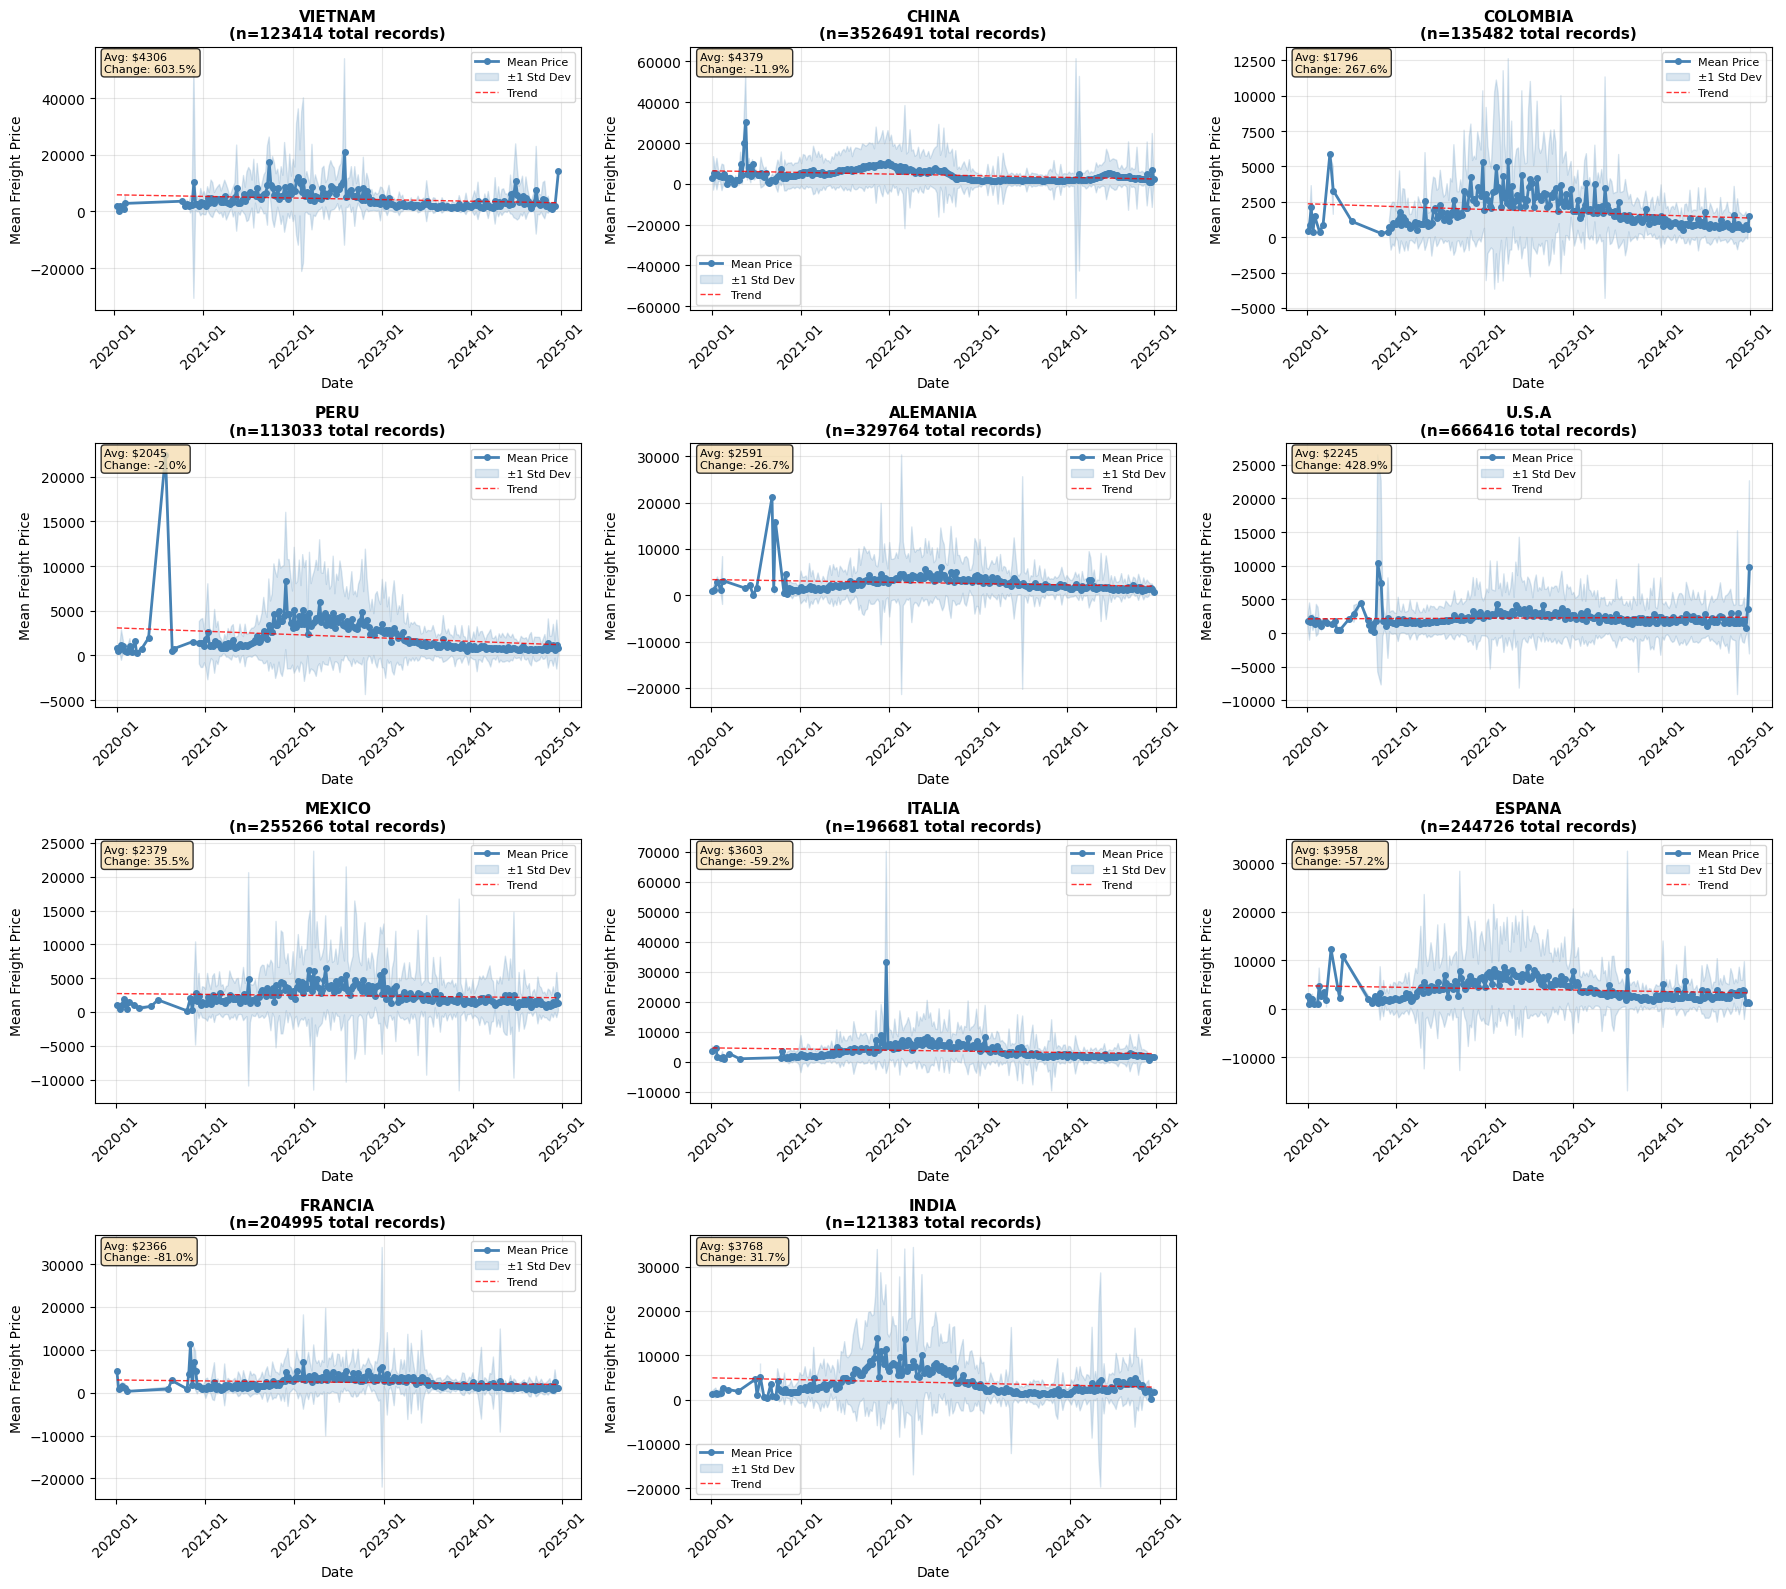

In [227]:
# Create individual subplot for each country for detailed analysis
n_countries = len(main_countries)
n_cols = 3
n_rows = (n_countries + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten() if n_countries > 1 else [axes]

for i, country in enumerate(main_countries):
    if i < len(axes):
        ax = axes[i]
        country_data = country_price_timeseries[country_price_timeseries['PAIS_DE_ORIGEN'] == country].copy()

        if len(country_data) > 0:
            # Sort by date
            country_data = country_data.sort_values('FECHA_DATETIME')

            # Main price line
            line = ax.plot(country_data['FECHA_DATETIME'], country_data['MEAN_FLETE_POR_BULTO'],
                          marker='o', linewidth=2, markersize=4, color='steelblue',
                          label='Mean Price')

            # Add confidence interval using std
            if not country_data['STD_FLETE_POR_BULTO'].isna().all():
                upper = country_data['MEAN_FLETE_POR_BULTO'] + country_data['STD_FLETE_POR_BULTO']
                lower = country_data['MEAN_FLETE_POR_BULTO'] - country_data['STD_FLETE_POR_BULTO']
                ax.fill_between(country_data['FECHA_DATETIME'], lower, upper,
                               alpha=0.2, color='steelblue', label='±1 Std Dev')

            # Add trend line
            if len(country_data) > 2:
                z = np.polyfit(mdates.date2num(country_data['FECHA_DATETIME']),
                              country_data['MEAN_FLETE_POR_BULTO'], 1)
                trend_line = np.poly1d(z)
                ax.plot(country_data['FECHA_DATETIME'],
                       trend_line(mdates.date2num(country_data['FECHA_DATETIME'])),
                       "--", alpha=0.8, color='red', linewidth=1, label='Trend')

            ax.set_title(f'{country}\n(n={country_data["COUNT_RECORDS"].sum()} total records)',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Date')
            ax.set_ylabel('Mean Freight Price')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
            ax.tick_params(axis='x', rotation=45)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

            # Add statistics text
            mean_price = country_data['MEAN_FLETE_POR_BULTO'].mean()
            price_change = ((country_data['MEAN_FLETE_POR_BULTO'].iloc[-1] -
                           country_data['MEAN_FLETE_POR_BULTO'].iloc[0]) /
                          country_data['MEAN_FLETE_POR_BULTO'].iloc[0] * 100)

            ax.text(0.02, 0.98, f'Avg: ${mean_price:.0f}\nChange: {price_change:.1f}%',
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=8)

# Hide empty subplots
for i in range(len(main_countries), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

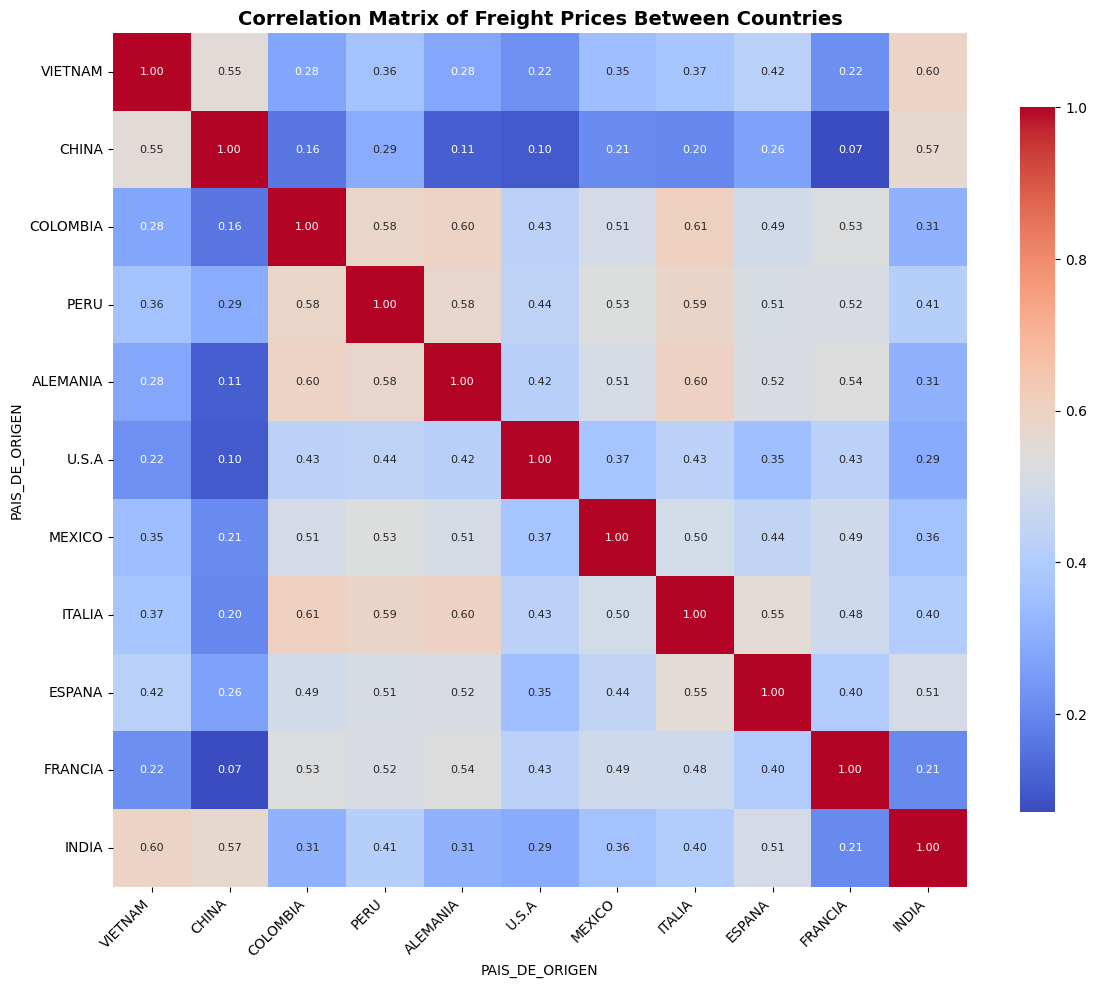

In [233]:
#get correlation matrix for main countries
main_country_data = price_pivot[main_countries]
correlation_matrix = main_country_data.corr(method='kendall')
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title('Correlation Matrix of Freight Prices Between Countries', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()